In [ ]:
import os
import numpy as np
import pandas as pd 
import networkx as nx
import gzip
import pickle
import matplotlib.pyplot as plt
import sys 
from pathlib import Path
import bicm
print(bicm.__version__)
from bicm import BipartiteGraph
import bicm.models_functions as mof
import bicm.solver_functions as sof
import bicm.network_functions as nef
import bicm.poibin as pb
from functools import partial
from platform import system
if system() != 'Windows':
    from multiprocessing import Pool



3.3.1


Import

In [2]:

ROOT = Path(__file__).resolve().parents[1] if "__file__" in globals() else Path.cwd().parents[0]
SRC  = ROOT / "src"
DATA = ROOT / "data"
FIGS = ROOT / "figures"

print("Project root:", ROOT)
print("Data folder:", DATA)
print("Figures folder:", FIGS)


#import functions and libraries:
# Permette di importare moduli da src/
sys.path.insert(0, str(SRC))
from utils import * 

#import data 
df = pd.read_parquet(DATA / "users_subreddits_subset.parquet")
print("Data imported:", df.shape)


Project root: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)
Data folder: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)/data
Figures folder: /Users/Daniele/Downloads/PolitoSphere Finale (Postzip)/figures
Data imported: (627776, 3)


Binarization

In [4]:
# === User–Subreddit Bipartite Matrix ===
df_filtered = df.copy()
print(f"User–subreddit data: {df_filtered.shape[0]} users × {df_filtered.shape[1]} columns")

# Pivot: users × subreddits
pivot_df = (
    df_filtered
    .pivot_table(index="author", columns="subreddit", values="number_of_comments", fill_value=0)
)

# Convert to NumPy matrix
matrix_user_subreddit = pivot_df.to_numpy()
print(f"Matrix shape: {matrix_user_subreddit.shape}")
print(f"Non-zero entries: {np.sum(matrix_user_subreddit > 0):,}")

# Row and column labels
l1 = pivot_df.index.astype(str).tolist()     # users
l2 = pivot_df.columns.astype(str).tolist()   # subreddits

# RCA binarization
inputmatrix = RCA_binarize(matrix_user_subreddit, 1.0)
print(f"Binary matrix shape: {inputmatrix.shape}")
print(f"Active links: {np.sum(inputmatrix > 0):,}")


User–subreddit data: 627776 users × 3 columns
Matrix shape: (387691, 214)
Non-zero entries: 627,776
Binary matrix shape: (387691, 214)
Active links: 562,139


Build bipartite user–subreddit graph

In [5]:
graph = nx.Graph()

# Add user nodes (bipartite=0) and subreddit nodes (bipartite=1)
for i in range(len(l1)):
    graph.add_node(l1[i], bipartite=0)
for j in range(len(l2)):
    graph.add_node(l2[j], bipartite=1)

# Add edges for all active user–subreddit links
for i in range(inputmatrix.shape[0]):
    for j in range(inputmatrix.shape[1]):
        if inputmatrix[i, j] > 0:
            graph.add_edge(l1[i], l2[j])

G = graph
print(f"✅ Bipartite graph created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges.")

# === Build adjacency list for subreddit projection ===
adj_list = {}
for j, topic in enumerate(l2):
    connected_users = [l1[i] for i in range(len(l1)) if inputmatrix[i, j] > 0]
    adj_list[topic] = connected_users

print(f"Adjacency list built for {len(adj_list)} subreddits.")

✅ Bipartite graph created: 387905 nodes, 562139 edges.
Adjacency list built for 214 subreddits.


Validated Projection: 
Users-Subreddits Network --> Subreddit Network

In [6]:

# === Bipartite projection using BiCM ===
# Poisson approximation of the Bipartite Configuration Model (see Saracco et al., *New J. Phys.* 19, 053022, 2017)
# alpha: statistical significance threshold for edge validation
# validation_method='fdr': controls the False Discovery Rate for multiple hypothesis testing

mynewGraph = BipartiteGraph(adjacency_list=adj_list)
subreddit_projection = mynewGraph.get_rows_projection(
    alpha=0.0001,
    method="poisson",
    validation_method="fdr",
    progress_bar=True
)

First I have to compute the BiCM. Computing...


/Users/Daniele/opt/anaconda3/lib/python3.9/site-packages/numba/core/utils.py:661: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",
/Users/Daniele/opt/anaconda3/lib/python3.9/site-packages/bicm/models_functions.py:326: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  step_fun = args[0]
/Users/Daniele/opt/anaconda3/lib/python3.9/site-packages/bicm/models_functions.py:327: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  arg_step_fun = args[1]
/Users/Daniele/opt/anaconda3/lib/python3.9/site-packages/numba/core/utils.py:661: NumbaExperimentalFeatureWarning: First-class function type feature is experimental
  warnings.warn("First-class function type feature is experimental",


max rows error = 4.984030965715647e-10
max columns error = 1.1039851699479186e-08
total error = 7.961354819840949e-08
Solver converged.


100%|██████████| 214/214 [00:33<00:00,  6.44it/s]


Network Analysis

In [ ]:
# === Convert validated projection into a NetworkX graph ===
graph = nx.Graph()

for key in subreddit_projection.keys():
    if not graph.has_node(key):
        graph.add_node(key)
    for val in subreddit_projection[key]:
        if not graph.has_node(val):
            graph.add_node(val)
        if not graph.has_edge(key, val):
            graph.add_edge(key, val)

print(f"✅ Projected network: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges.")

/var/folders/43/tx67zsg90pg77hblfmmfv_tm0000gn/T/ipykernel_7398/1665593902.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


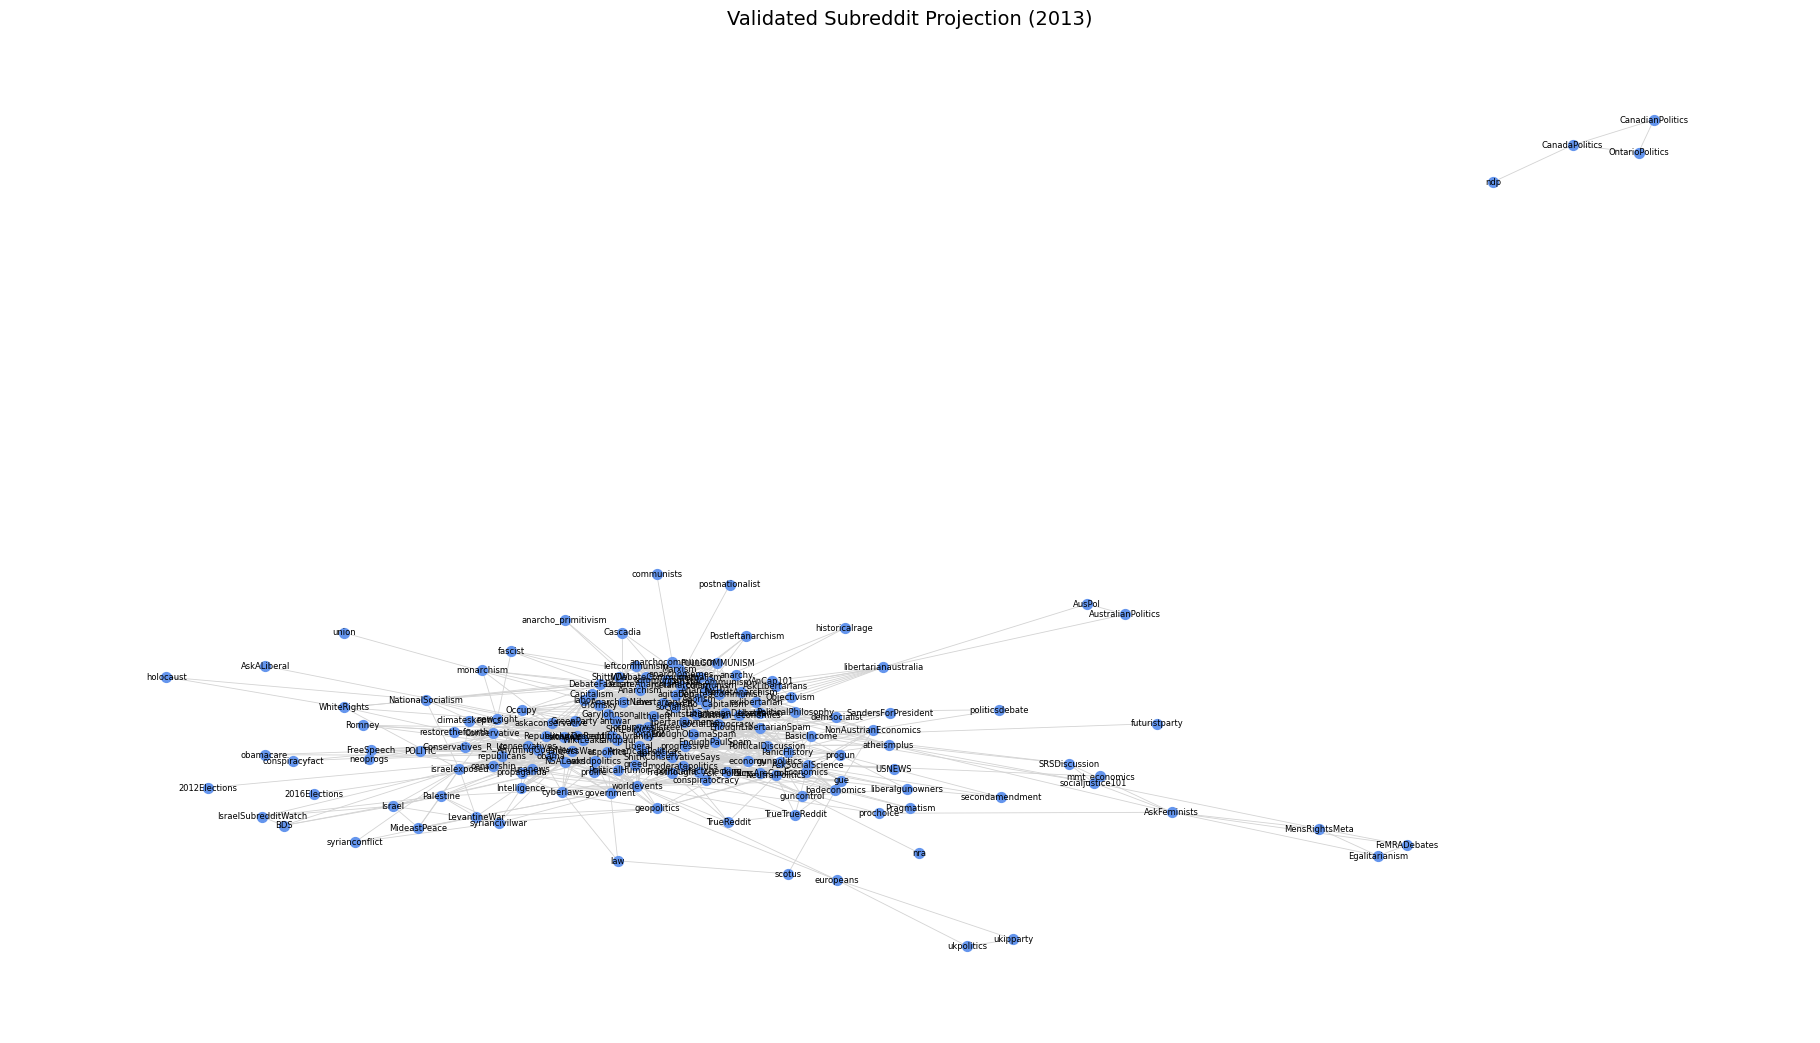

In [ ]:

# === Quick visualization with spring layout ===
plt.figure(figsize=(18, 10))
pos = nx.spring_layout(graph, seed=42)  # reproducible layout
nx.draw(
    graph,
    pos,
    node_size=50,
    node_color="cornflowerblue",
    edge_color="lightgray",
    width=0.6,
    with_labels=True, 
    font_size=6
    
)
plt.title("Validated Subreddit Projection (2013)", fontsize=14)
plt.axis("off")
plt.tight_layout()
#plt.savefig(FIGS / "bipartite_validated_subreddit_projection_2013.png", dpi=300)
plt.show()
